In [ ]:
import pandas as pd

df = pd.read_csv("combined_results.csv")


,model_path,folder,val_loss,val_acc,time_per_image,throughput,nums_trainable_parameters
0,model_weights/final_checkpoint_resnet18_batch_...,masked,1.370018,0.635802,0.000070,14233.909027,51813
1,model_weights/final_checkpoint_resnet18_batch_...,clean,1.191958,0.678733,0.000051,19683.366444,51813
2,model_weights/final_checkpoint_resnet18_batch_...,downsampled,3.599344,0.229465,0.000049,20258.121235,51813
3,model_weights/final_checkpoint_resnet18_batch_...,blur_medium,2.459206,0.397307,0.000052,19417.276592,51813
4,model_weights/final_checkpoint_resnet18_batch_...,blur_little,1.525196,0.595842,0.000051,19674.948674,51813


In [38]:
# num of trained parameters vs improvement over baseline

df_grouped = df.groupby("model_path").agg({
    "val_loss": "mean",
    "val_acc": "mean",
    "throughput": "mean",
    "nums_trainable_parameters": "mean"
}).reset_index()

df_over_baseline = df_grouped.copy()
baseline_acc_res = df_grouped[df_grouped["model_path"].str.contains("resnet18_linear_probe")]["val_acc"]
baseline_acc_eff = df_grouped[df_grouped["model_path"].str.contains("efficientnet_linear_probe")]["val_acc"]



resnet_df = df_over_baseline[df_over_baseline["model_path"].str.contains("resnet")]
resnet_df["acc_over_baseline"] = resnet_df["val_acc"] - baseline_acc_res.values[0]
efficientnet_df = df_over_baseline[df_over_baseline["model_path"].str.contains("efficientnet")]
efficientnet_df["acc_over_baseline"] = efficientnet_df["val_acc"] - baseline_acc_eff.values[0]

In [39]:
resnet_df

,model_path,val_loss,val_acc,throughput,nums_trainable_parameters,acc_over_baseline
4,model_weights/final_checkpoint_resnet18_batch_...,1.948420,0.520950,18913.692941,51813.0,0.094026
5,model_weights/final_checkpoint_resnet18_custom...,1.688231,0.571465,9786.243891,194469.0,0.144541
6,model_weights/final_checkpoint_resnet18_linear...,2.413330,0.426924,19428.036002,51813.0,0.000000
7,model_weights/final_checkpoint_resnet18_lora.pt,2.040917,0.513630,18576.245452,572517.0,0.086706
8,model_weights/final_checkpoint_resnet18_task_s...,1.960891,0.521809,16555.919997,139933.0,0.094884


In [40]:

import altair as alt

res_chart = alt.Chart(resnet_df).mark_point().encode(
    x="nums_trainable_parameters",
    y="acc_over_baseline",
    color="model_path"
)

efficientnet_chart = alt.Chart(efficientnet_df).mark_point().encode(
    x="nums_trainable_parameters",
    y="acc_over_baseline",
    color="model_path"
)

res_chart | efficientnet_chart

alt.HConcatChart(...)

analysis to be done
- Compare acc across all models
- Compare between EfficientNet and ResNet models
- Between different test sets
- Compare numbers of parameters vs accuracy over baseline (linear_probe) for all models
- Compare inference time per image for all models
- Visualizations showing trade-offs between performance and model efficiency, such as bubble plots of performance vs FLOPs2
or wall-clock time, with bubble  size proportional to trainable parameter count. 
- Similar plots should be created for inference speed vs performance.

Make nice charts out of these.
Make grad cam files




## Added analysis
The cells below complete the comparison and visualization section using `combined_results.csv`. 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

analysis_df = pd.read_csv("combined_results.csv").copy()

def get_backbone(model_path):
    if "efficientnet" in model_path.lower():
        return "EfficientNetV2-S"
    if "resnet" in model_path.lower():
        return "ResNet18"
    return "Other"

def get_method(model_path):
    model_path = model_path.lower()
    if "linear_probe" in model_path:
        return "Linear Probe"
    if "batch_norm" in model_path:
        return "BatchNorm Tuning"
    if "task_specific_adapter" in model_path or "task_specific_adapters" in model_path:
        return "Task-Specific Adapter"
    if "lora" in model_path:
        return "LoRA"
    if "custom_model" in model_path:
        return "Custom Model"
    return "Other"

analysis_df["backbone"] = analysis_df["model_path"].apply(get_backbone)
analysis_df["method"] = analysis_df["model_path"].apply(get_method)
analysis_df["model_name"] = analysis_df["backbone"] + " | " + analysis_df["method"]

test_set_order = ["clean", "masked", "noise_rotation", "blur_little", "blur_medium", "downsampled"]
analysis_df["folder"] = pd.Categorical(analysis_df["folder"], categories=test_set_order, ordered=True)

model_summary = (
    analysis_df.groupby(["model_path", "backbone", "method", "model_name"], as_index=False)
    .agg(
        mean_accuracy=("val_acc", "mean"),
        mean_loss=("val_loss", "mean"),
        clean_accuracy=("val_acc", lambda s: s[analysis_df.loc[s.index, "folder"] == "clean"].iloc[0]),
        avg_time_per_image=("time_per_image", "mean"),
        avg_throughput=("throughput", "mean"),
        trainable_parameters=("nums_trainable_parameters", "mean")
    )
)

baseline_map = (
    model_summary[model_summary["method"] == "Linear Probe"]
    .set_index("backbone")["mean_accuracy"]
    .to_dict()
)
model_summary["accuracy_over_baseline"] = model_summary.apply(
    lambda row: row["mean_accuracy"] - baseline_map[row["backbone"]], axis=1
)
model_summary["params_millions"] = model_summary["trainable_parameters"] / 1_000_000
model_summary["images_per_second"] = 1.0 / model_summary["avg_time_per_image"]

display_cols = [
    "backbone", "method", "clean_accuracy", "mean_accuracy", "accuracy_over_baseline",
    "avg_time_per_image", "avg_throughput", "trainable_parameters"
]
model_summary = model_summary.sort_values(["mean_accuracy", "clean_accuracy"], ascending=False).reset_index(drop=True)
model_summary[display_cols]


,backbone,method,clean_accuracy,mean_accuracy,accuracy_over_baseline,avg_time_per_image,avg_throughput,trainable_parameters
0,EfficientNetV2-S,BatchNorm Tuning,0.864673,0.709531,0.267987,0.002878,347.640551,283253.0
1,EfficientNetV2-S,LoRA,0.849426,0.667729,0.226185,0.002120,471.675004,1511997.0
2,EfficientNetV2-S,Task-Specific Adapter,0.806455,0.630442,0.188898,0.002805,356.568597,153729.0
3,ResNet18,Custom Model,0.695604,0.571465,0.144541,0.000102,9786.243891,194469.0
4,ResNet18,Task-Specific Adapter,0.673703,0.521809,0.094884,0.000060,16555.919997,139933.0
5,ResNet18,BatchNorm Tuning,0.678733,0.520950,0.094026,0.000054,18913.692941,51813.0
6,ResNet18,LoRA,0.673782,0.513630,0.086706,0.000054,18576.245452,572517.0
7,EfficientNetV2-S,Linear Probe,0.617703,0.441545,0.000000,0.002786,358.915069,129381.0
8,ResNet18,Linear Probe,0.575762,0.426924,0.000000,0.000051,19428.036002,51813.0


In [3]:
summary_report = model_summary[[
    "backbone", "method", "clean_accuracy", "mean_accuracy", "accuracy_over_baseline",
    "avg_time_per_image", "avg_throughput", "trainable_parameters"
]].copy()
summary_report["clean_accuracy"] = summary_report["clean_accuracy"].map(lambda x: f"{x:.3f}")
summary_report["mean_accuracy"] = summary_report["mean_accuracy"].map(lambda x: f"{x:.3f}")
summary_report["accuracy_over_baseline"] = summary_report["accuracy_over_baseline"].map(lambda x: f"{x:+.3f}")
summary_report["avg_time_per_image"] = summary_report["avg_time_per_image"].map(lambda x: f"{x * 1000:.3f} ms")
summary_report["avg_throughput"] = summary_report["avg_throughput"].map(lambda x: f"{x:,.1f}")
summary_report["trainable_parameters"] = summary_report["trainable_parameters"].map(lambda x: f"{int(x):,}")
print("Top model by mean accuracy:", model_summary.loc[0, "model_name"], f"({model_summary.loc[0, 'mean_accuracy']:.3f})")
print("Top model on the clean test set:", model_summary.sort_values('clean_accuracy', ascending=False).iloc[0]['model_name'])
print("Fastest average inference:", model_summary.sort_values('avg_time_per_image').iloc[0]['model_name'])
summary_report


Top model by mean accuracy: EfficientNetV2-S | BatchNorm Tuning (0.710)
Top model on the clean test set: EfficientNetV2-S | BatchNorm Tuning
Fastest average inference: ResNet18 | Linear Probe


,backbone,method,clean_accuracy,mean_accuracy,accuracy_over_baseline,avg_time_per_image,avg_throughput,trainable_parameters
0,EfficientNetV2-S,BatchNorm Tuning,0.865,0.710,+0.268,2.878 ms,347.6,"283,253"
1,EfficientNetV2-S,LoRA,0.849,0.668,+0.226,2.120 ms,471.7,"1,511,997"
2,EfficientNetV2-S,Task-Specific Adapter,0.806,0.630,+0.189,2.805 ms,356.6,"153,729"
3,ResNet18,Custom Model,0.696,0.571,+0.145,0.102 ms,"9,786.2","194,469"
4,ResNet18,Task-Specific Adapter,0.674,0.522,+0.095,0.060 ms,"16,555.9","139,933"
5,ResNet18,BatchNorm Tuning,0.679,0.521,+0.094,0.054 ms,"18,913.7","51,813"
6,ResNet18,LoRA,0.674,0.514,+0.087,0.054 ms,"18,576.2","572,517"
7,EfficientNetV2-S,Linear Probe,0.618,0.442,+0.000,2.786 ms,358.9,"129,381"
8,ResNet18,Linear Probe,0.576,0.427,+0.000,0.051 ms,"19,428.0","51,813"


C:\Users\inaar\AppData\Local\Temp\ipykernel_9068\1301108120.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_set_summary, x="mean_accuracy", y="folder", ax=axes[0], palette="crest")


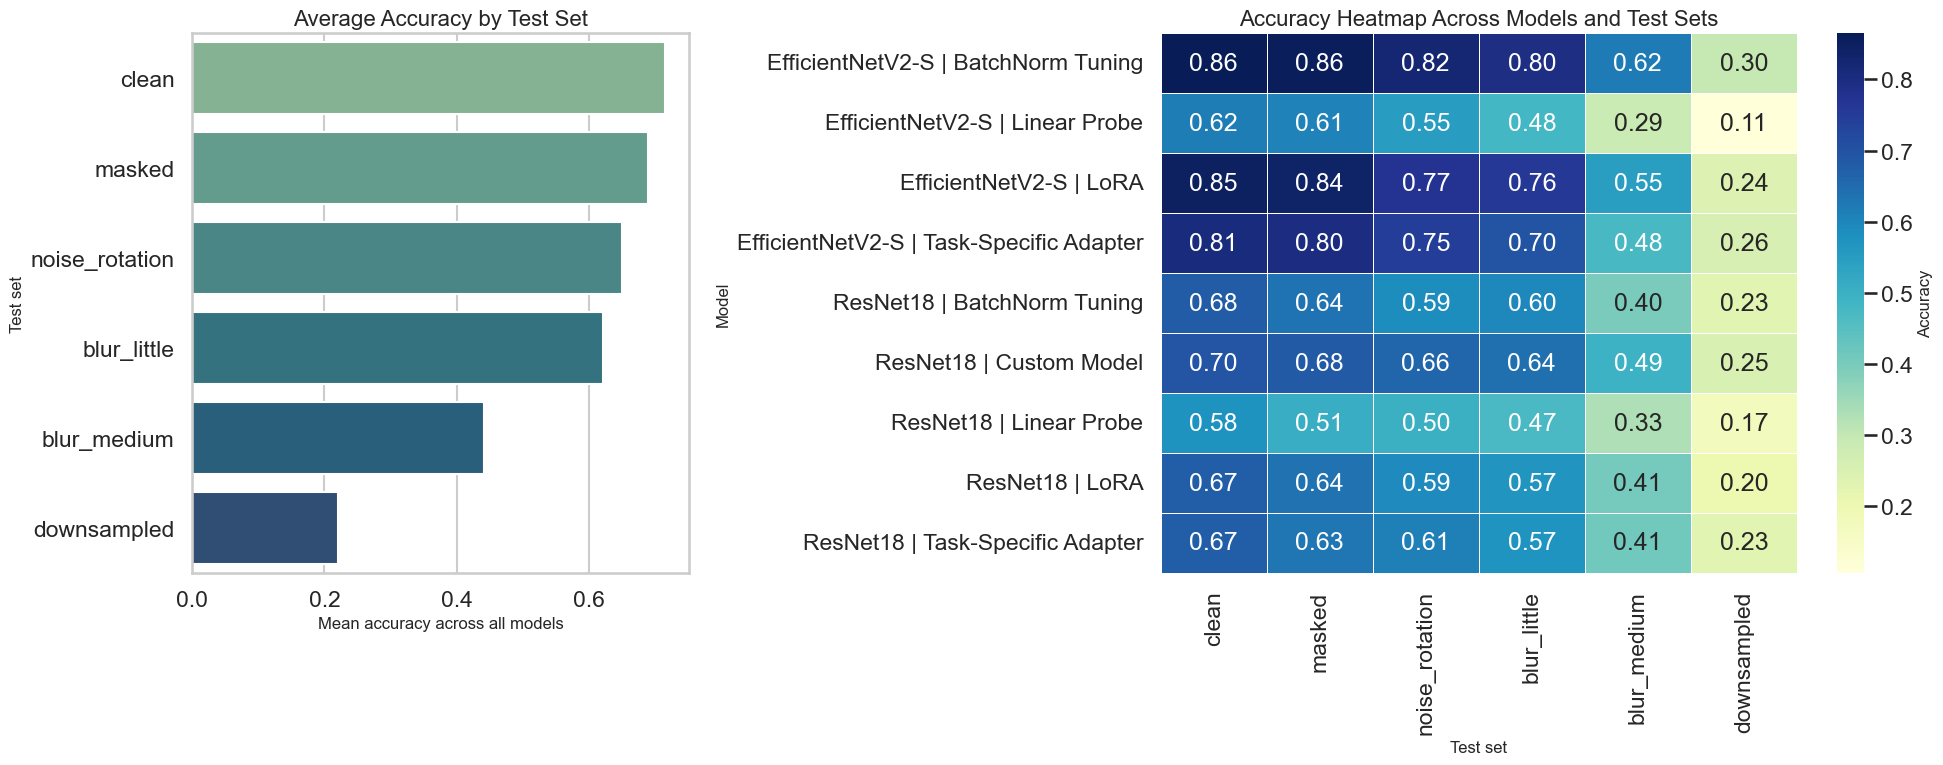

In [6]:
test_set_summary = (
    analysis_df.groupby("folder", as_index=False)
    .agg(mean_accuracy=("val_acc", "mean"), mean_loss=("val_loss", "mean"))
    .sort_values("mean_accuracy", ascending=False)
)

pivot_acc = analysis_df.pivot_table(index="model_name", columns="folder", values="val_acc")
pivot_acc = pivot_acc[test_set_order]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={"width_ratios": [1, 1.6]})
sns.barplot(data=test_set_summary, x="mean_accuracy", y="folder", ax=axes[0], palette="crest")
axes[0].set_title("Average Accuracy by Test Set")
axes[0].set_xlabel("Mean accuracy across all models")
axes[0].set_ylabel("Test set")

sns.heatmap(pivot_acc, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, ax=axes[1], cbar_kws={"label": "Accuracy"})
axes[1].set_title("Accuracy Heatmap Across Models and Test Sets")
axes[1].set_xlabel("Test set")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


### Test set comparison
The clean test set is the easiest for all models, while the downsampled test set is the hardest. Blur and masking reduce performance, but not as severely as downsampling. This suggests the models are especially sensitive to loss of image resolution, likely because important texture and shape details are removed.

### Model-by-test-set heatmap
The heatmap shows that stronger models remain more stable across corrupted test sets, not just on the clean set. EfficientNet PEFT variants, especially BatchNorm tuning and LoRA, tend to maintain better robustness than linear probing. In contrast, linear probe models show the largest drops, suggesting that frozen backbones adapt less well to distribution shift.


In [17]:
import textwrap
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.dpi"] = 140

backbone_code = {"ResNet18": "R", "EfficientNetV2-S": "E"}
method_code = {
    "Linear Probe": "LP",
    "BatchNorm Tuning": "BN",
    "Task-Specific Adapter": "TSA",
    "LoRA": "LoRA",
    "Custom Model": "Custom"
}

plot_df = model_summary.copy()
plot_df["short_model_name"] = plot_df.apply(
    lambda row: f"{backbone_code.get(row['backbone'], row['backbone'][0])}-{method_code.get(row['method'], row['method'])}",
    axis=1,
)
plot_df["display_name"] = plot_df.apply(
    lambda row: f"{row['backbone'].replace('EfficientNetV2-S', 'EffNetV2-S')}\n{row['method']}",
    axis=1,
)

analysis_df["display_name"] = analysis_df.apply(
    lambda row: f"{row['backbone'].replace('EfficientNetV2-S', 'EffNetV2-S')}\n{row['method']}",
    axis=1,
)

palette = {"ResNet18": "#4C72B0", "EfficientNetV2-S": "#DD8452"}

def style_axis(ax, xlabel=None, ylabel=None, title=None, xgrid=True):
    if title is not None:
        ax.set_title(title, pad=12, weight="bold")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if xgrid else "y", alpha=0.20)

def add_code_key(ax, df, loc=(1.02, 1.0)):
    key_lines = [f"{row.short_model_name}: {row.backbone.replace('EfficientNetV2-S', 'EffNetV2-S')} / {row.method}" for row in df.sort_values(['backbone', 'method']).itertuples()]
    ax.text(
        loc[0],
        loc[1],
        "Codes\n" + "\n".join(key_lines),
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC", alpha=0.95),
    )

def annotate_codes(ax, df, x, y, dx=6, dy=6):
    offsets = [(dx, dy), (dx, -12), (-18, dy), (-24, -12), (8, 14), (-20, 14)]
    for idx, row in enumerate(df.itertuples()):
        ox, oy = offsets[idx % len(offsets)]
        ax.annotate(row.short_model_name, (getattr(row, x), getattr(row, y)), textcoords="offset points", xytext=(ox, oy), fontsize=8, weight="bold")


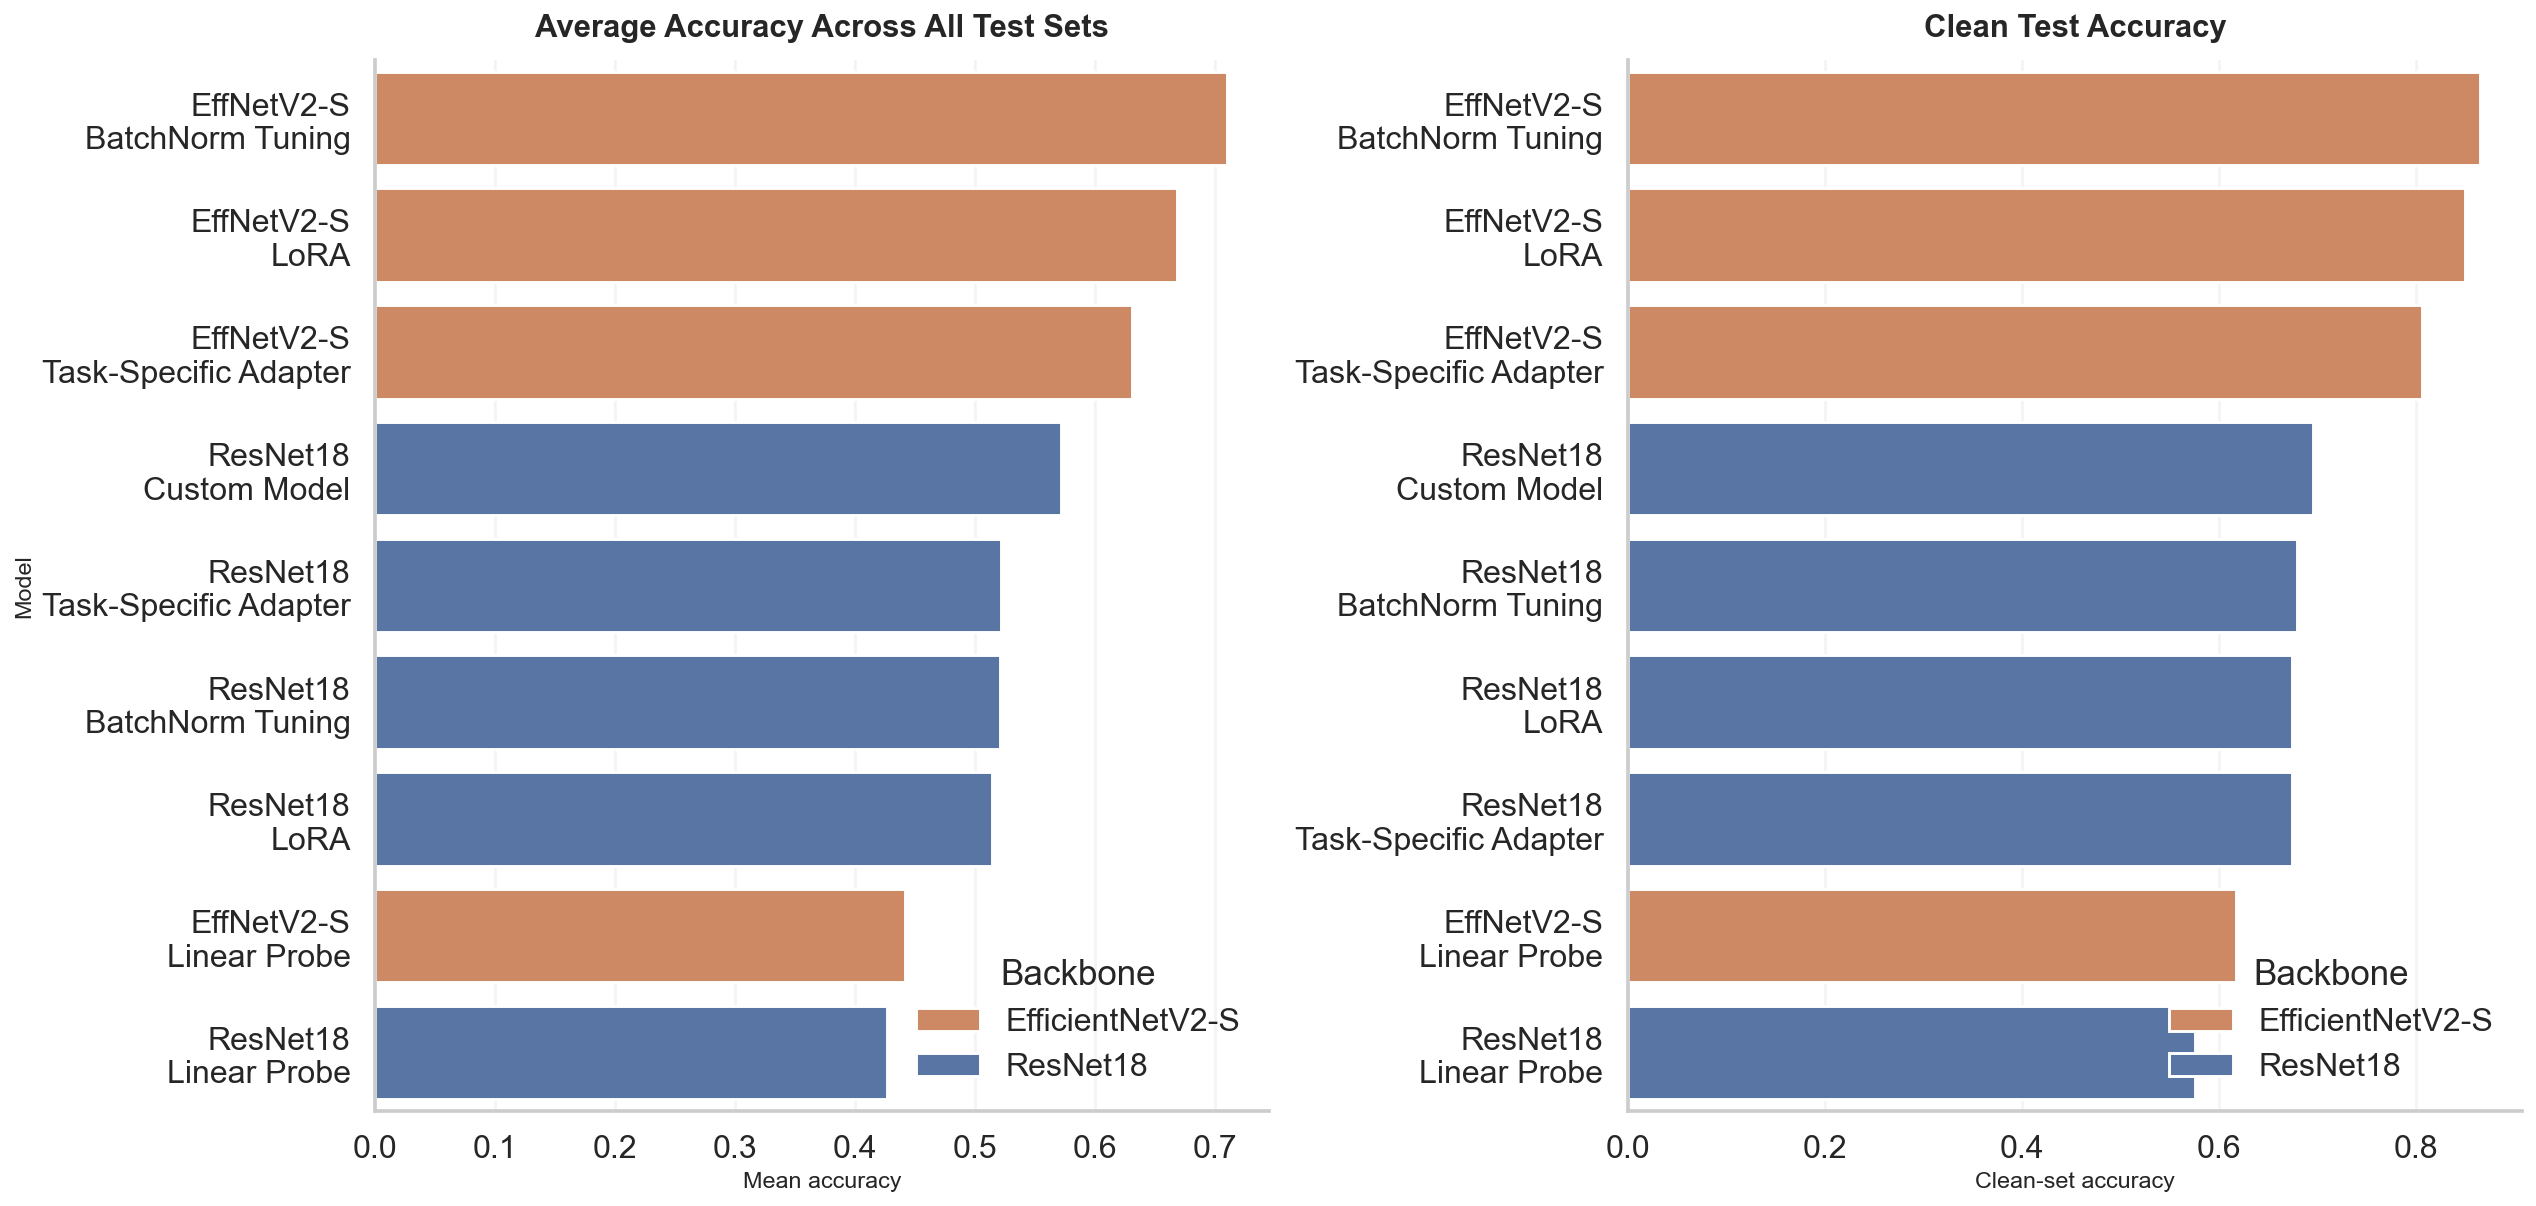

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8.5), constrained_layout=True)

mean_rank = plot_df.sort_values("mean_accuracy", ascending=False)
sns.barplot(data=mean_rank, x="mean_accuracy", y="display_name", hue="backbone", palette=palette, dodge=False, ax=axes[0])
style_axis(axes[0], xlabel="Mean accuracy", ylabel="Model", title="Average Accuracy Across All Test Sets")
axes[0].legend(title="Backbone", frameon=False, loc="lower right")

clean_rank = plot_df.sort_values("clean_accuracy", ascending=False)
sns.barplot(data=clean_rank, x="clean_accuracy", y="display_name", hue="backbone", palette=palette, dodge=False, ax=axes[1])
style_axis(axes[1], xlabel="Clean-set accuracy", ylabel="", title="Clean Test Accuracy")
axes[1].legend(title="Backbone", frameon=False, loc="lower right")

plt.show()


### Overall accuracy across models
EfficientNetV2-S models consistently outperform ResNet18 models in both clean-set accuracy and average accuracy across all test sets. The strongest overall model is EfficientNetV2-S with BatchNorm tuning, while the best ResNet result comes from the custom model. This suggests that backbone choice has a larger impact on performance than tuning strategy alone.


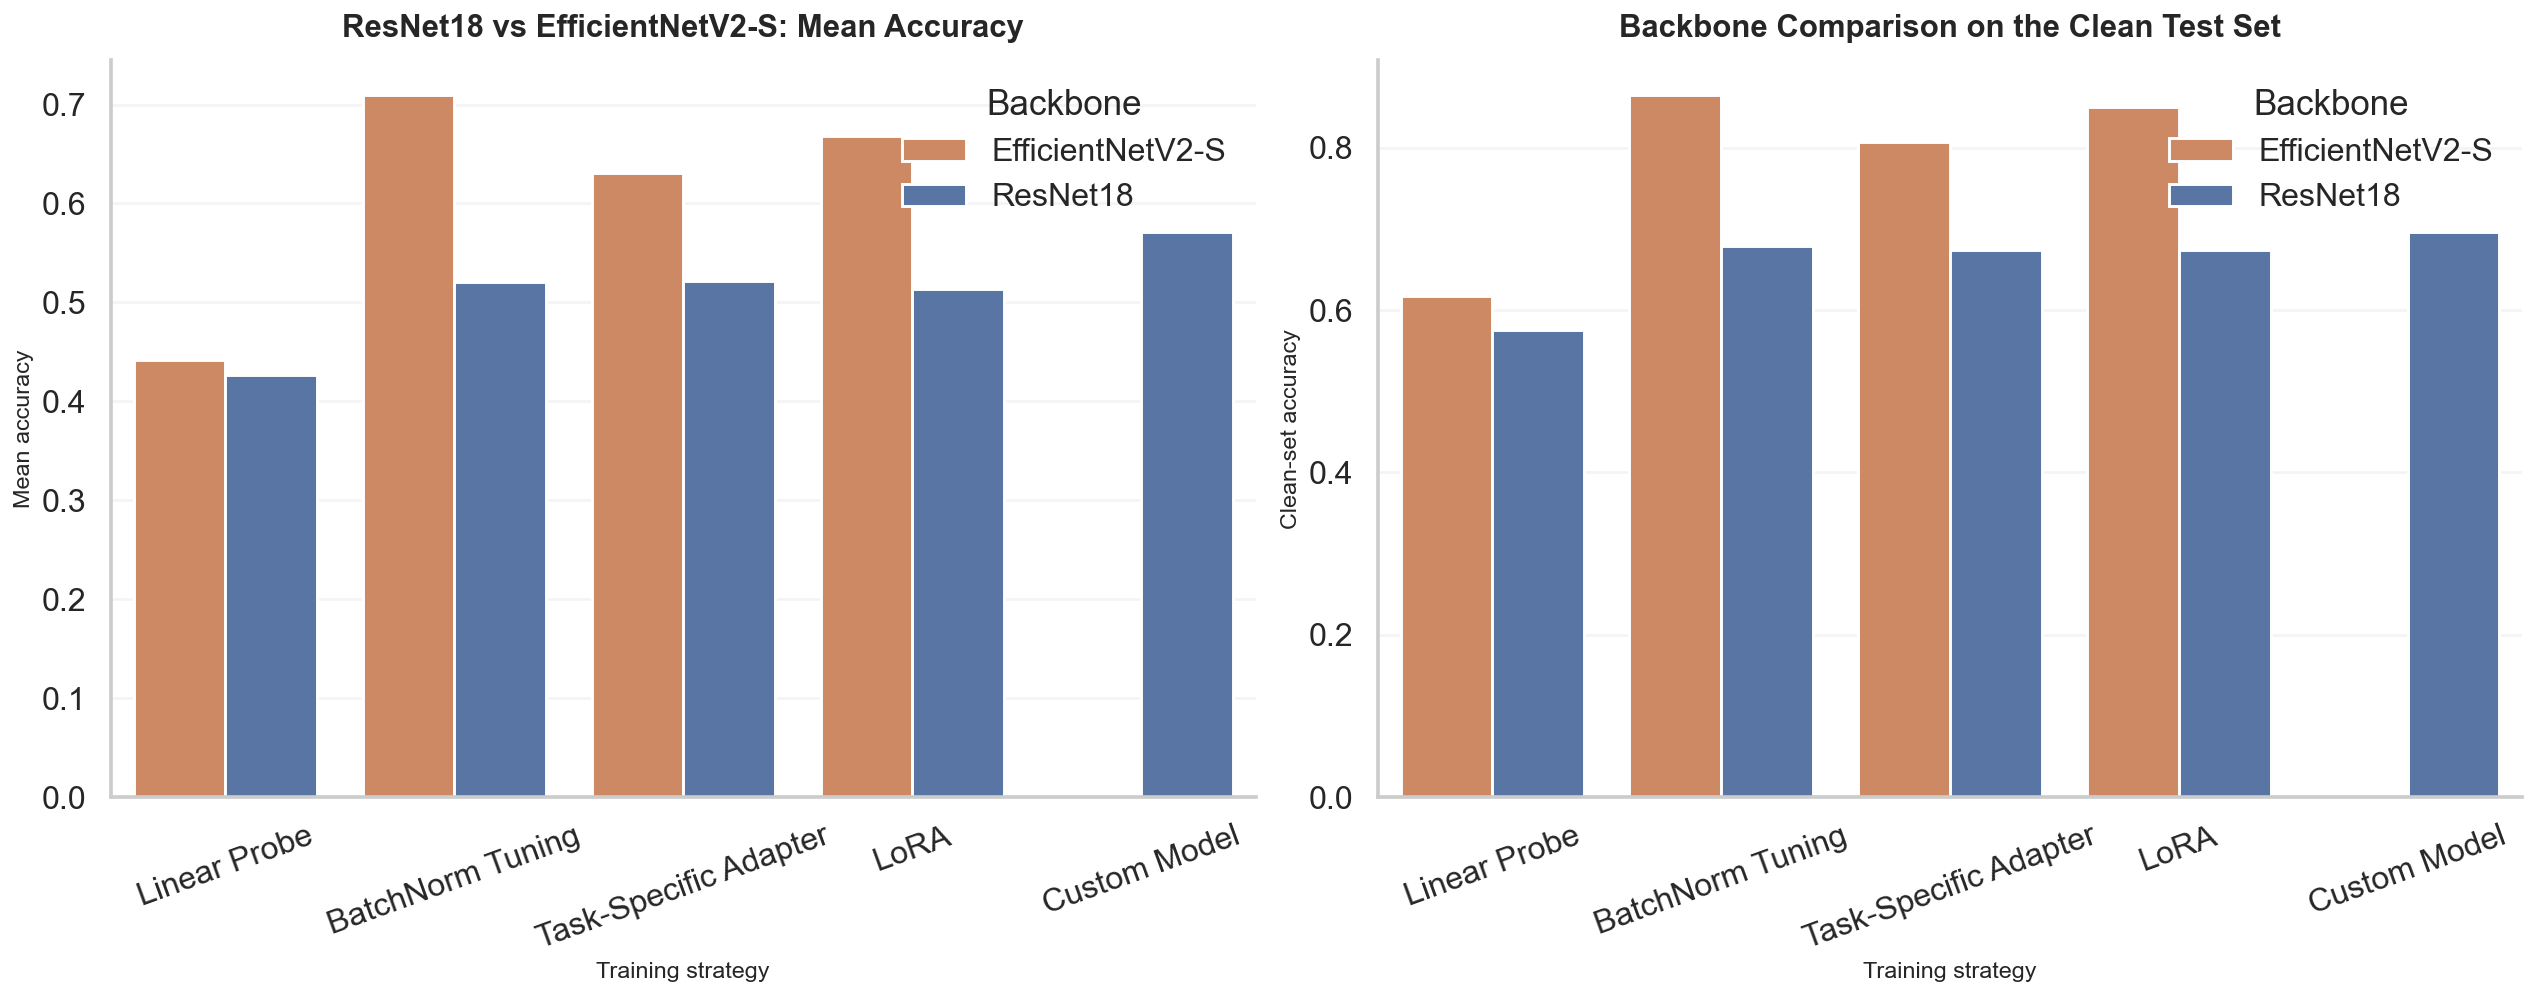

In [11]:
backbone_method_summary = (
    analysis_df.groupby(["backbone", "method"], as_index=False)
    .agg(
        mean_accuracy=("val_acc", "mean"),
        clean_accuracy=("val_acc", lambda s: s[analysis_df.loc[s.index, "folder"] == "clean"].iloc[0]),
    )
)

method_order = ["Linear Probe", "BatchNorm Tuning", "Task-Specific Adapter", "LoRA", "Custom Model"]
backbone_method_summary["method"] = pd.Categorical(backbone_method_summary["method"], categories=method_order, ordered=True)
backbone_method_summary = backbone_method_summary.sort_values("method")

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
sns.barplot(data=backbone_method_summary, x="method", y="mean_accuracy", hue="backbone", palette=palette, ax=axes[0])
style_axis(axes[0], xlabel="Training strategy", ylabel="Mean accuracy", title="ResNet18 vs EfficientNetV2-S: Mean Accuracy", xgrid=False)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Backbone", frameon=False)

sns.barplot(data=backbone_method_summary, x="method", y="clean_accuracy", hue="backbone", palette=palette, ax=axes[1])
style_axis(axes[1], xlabel="Training strategy", ylabel="Clean-set accuracy", title="Backbone Comparison on the Clean Test Set", xgrid=False)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Backbone", frameon=False)

plt.show()


### EfficientNet vs ResNet
Across nearly every training strategy, EfficientNetV2-S achieves higher accuracy than the corresponding ResNet18 model. However, ResNet18 is much faster at inference, so the higher-performing backbone is not necessarily the most efficient one. This shows a clear trade-off between accuracy and speed.


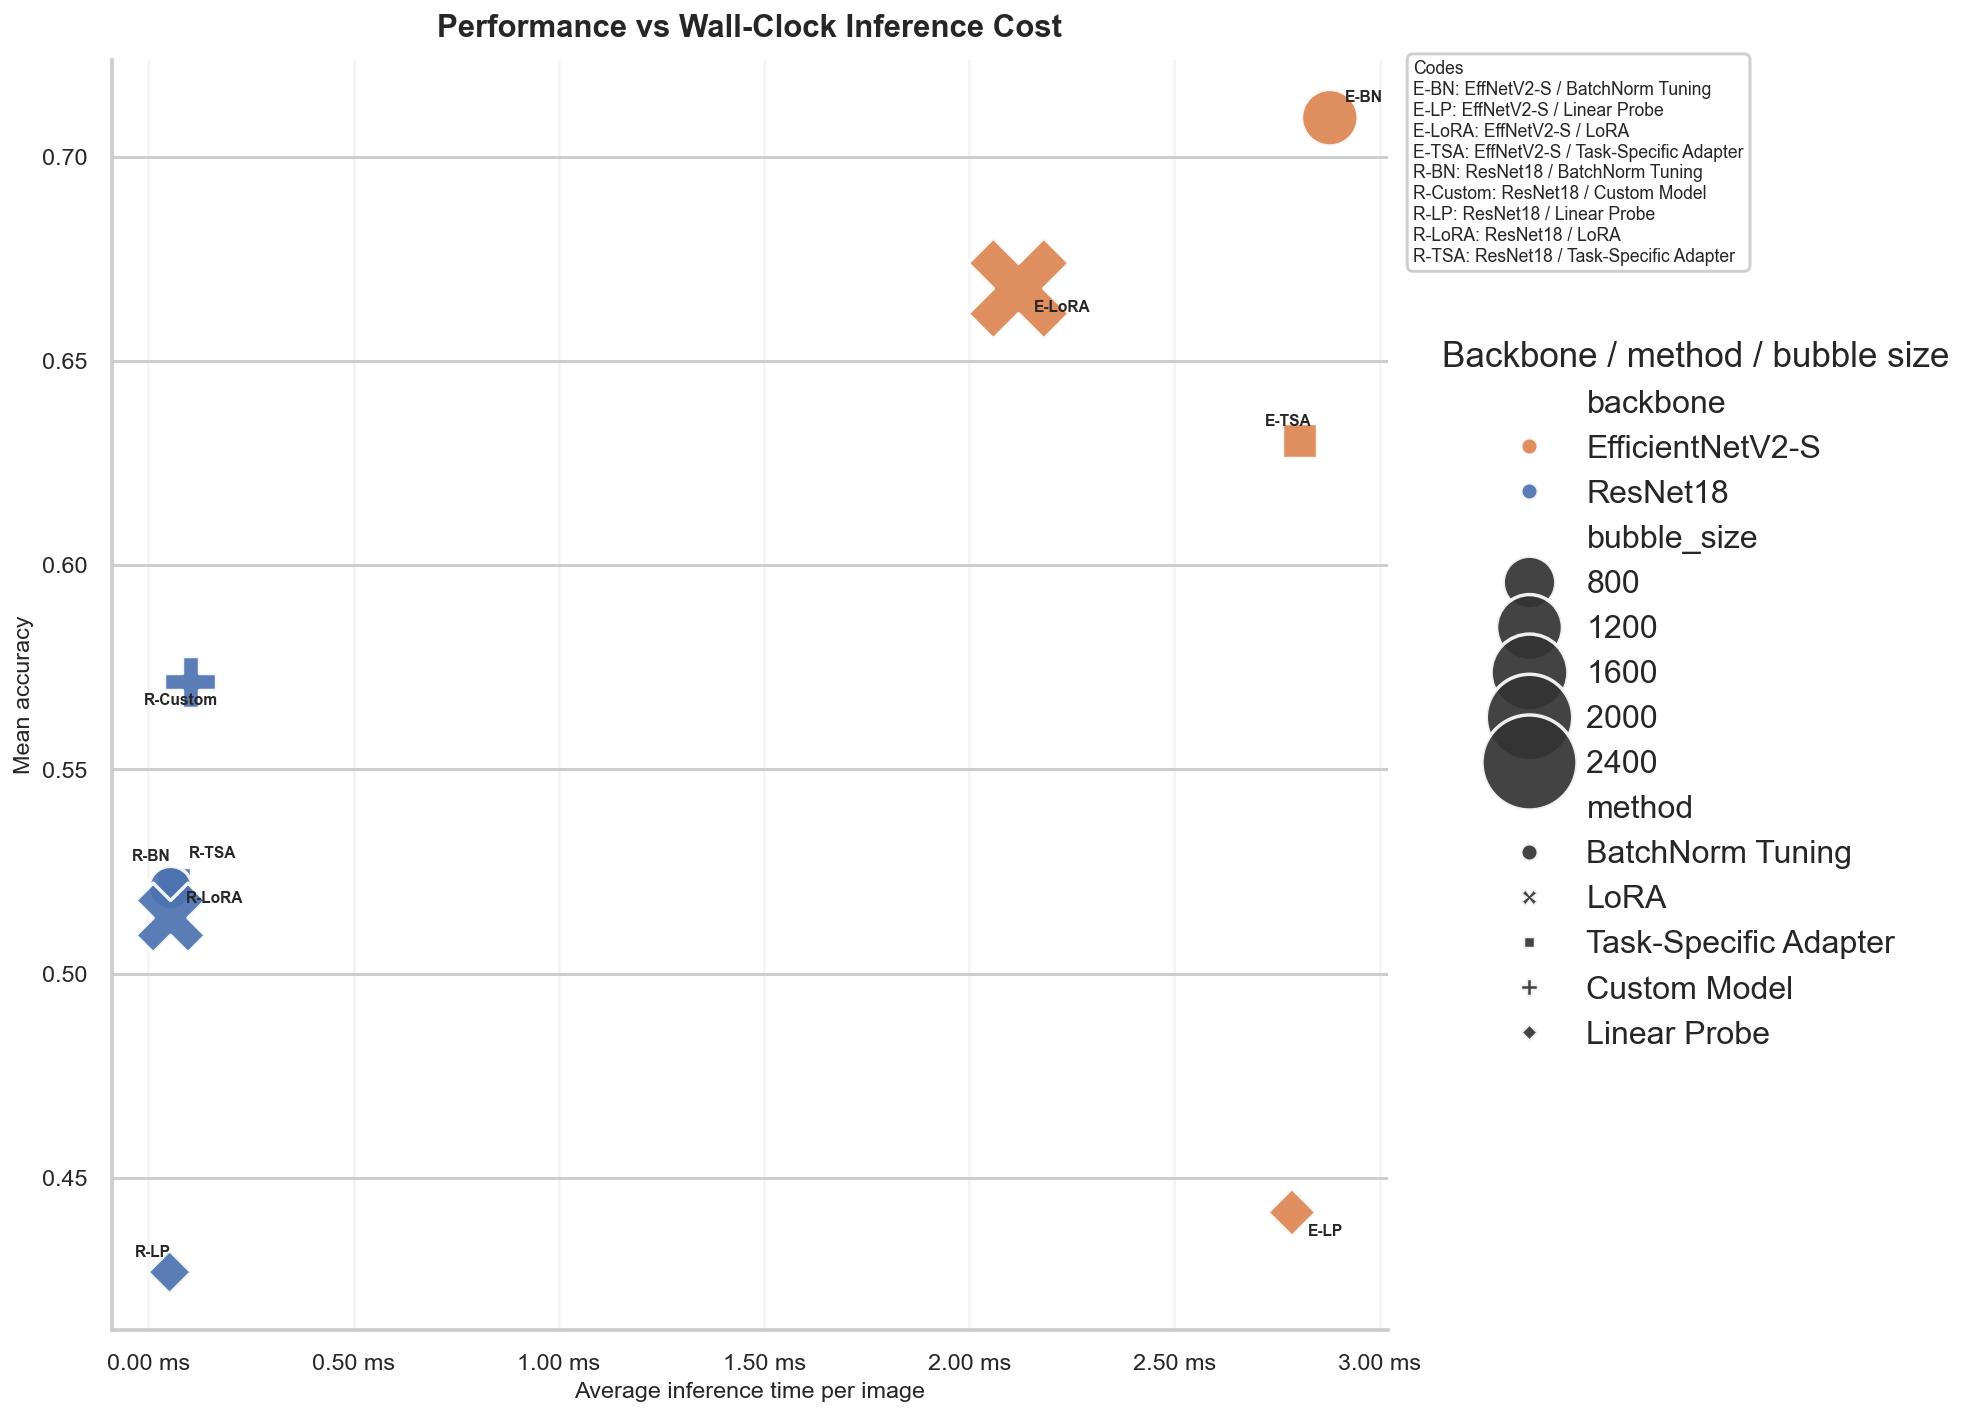

In [15]:
size_scale = plot_df["trainable_parameters"] / plot_df["trainable_parameters"].max()
plot_df["bubble_size"] = 500 + 2200 * size_scale

fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
sns.scatterplot(
    data=plot_df,
    x="avg_time_per_image",
    y="mean_accuracy",
    size="bubble_size",
    hue="backbone",
    style="method",
    palette=palette,
    sizes=(500, 2700),
    alpha=0.92,
    ax=ax,
)
annotate_codes(ax, plot_df, "avg_time_per_image", "mean_accuracy", dx=8, dy=8)
style_axis(ax, xlabel="Average inference time per image", ylabel="Mean accuracy", title="Performance vs Wall-Clock Inference Cost")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x * 1000:.2f} ms"))
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="Backbone / method / bubble size", frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")
add_code_key(ax, plot_df, loc=(1.02, 1.0))
plt.show()


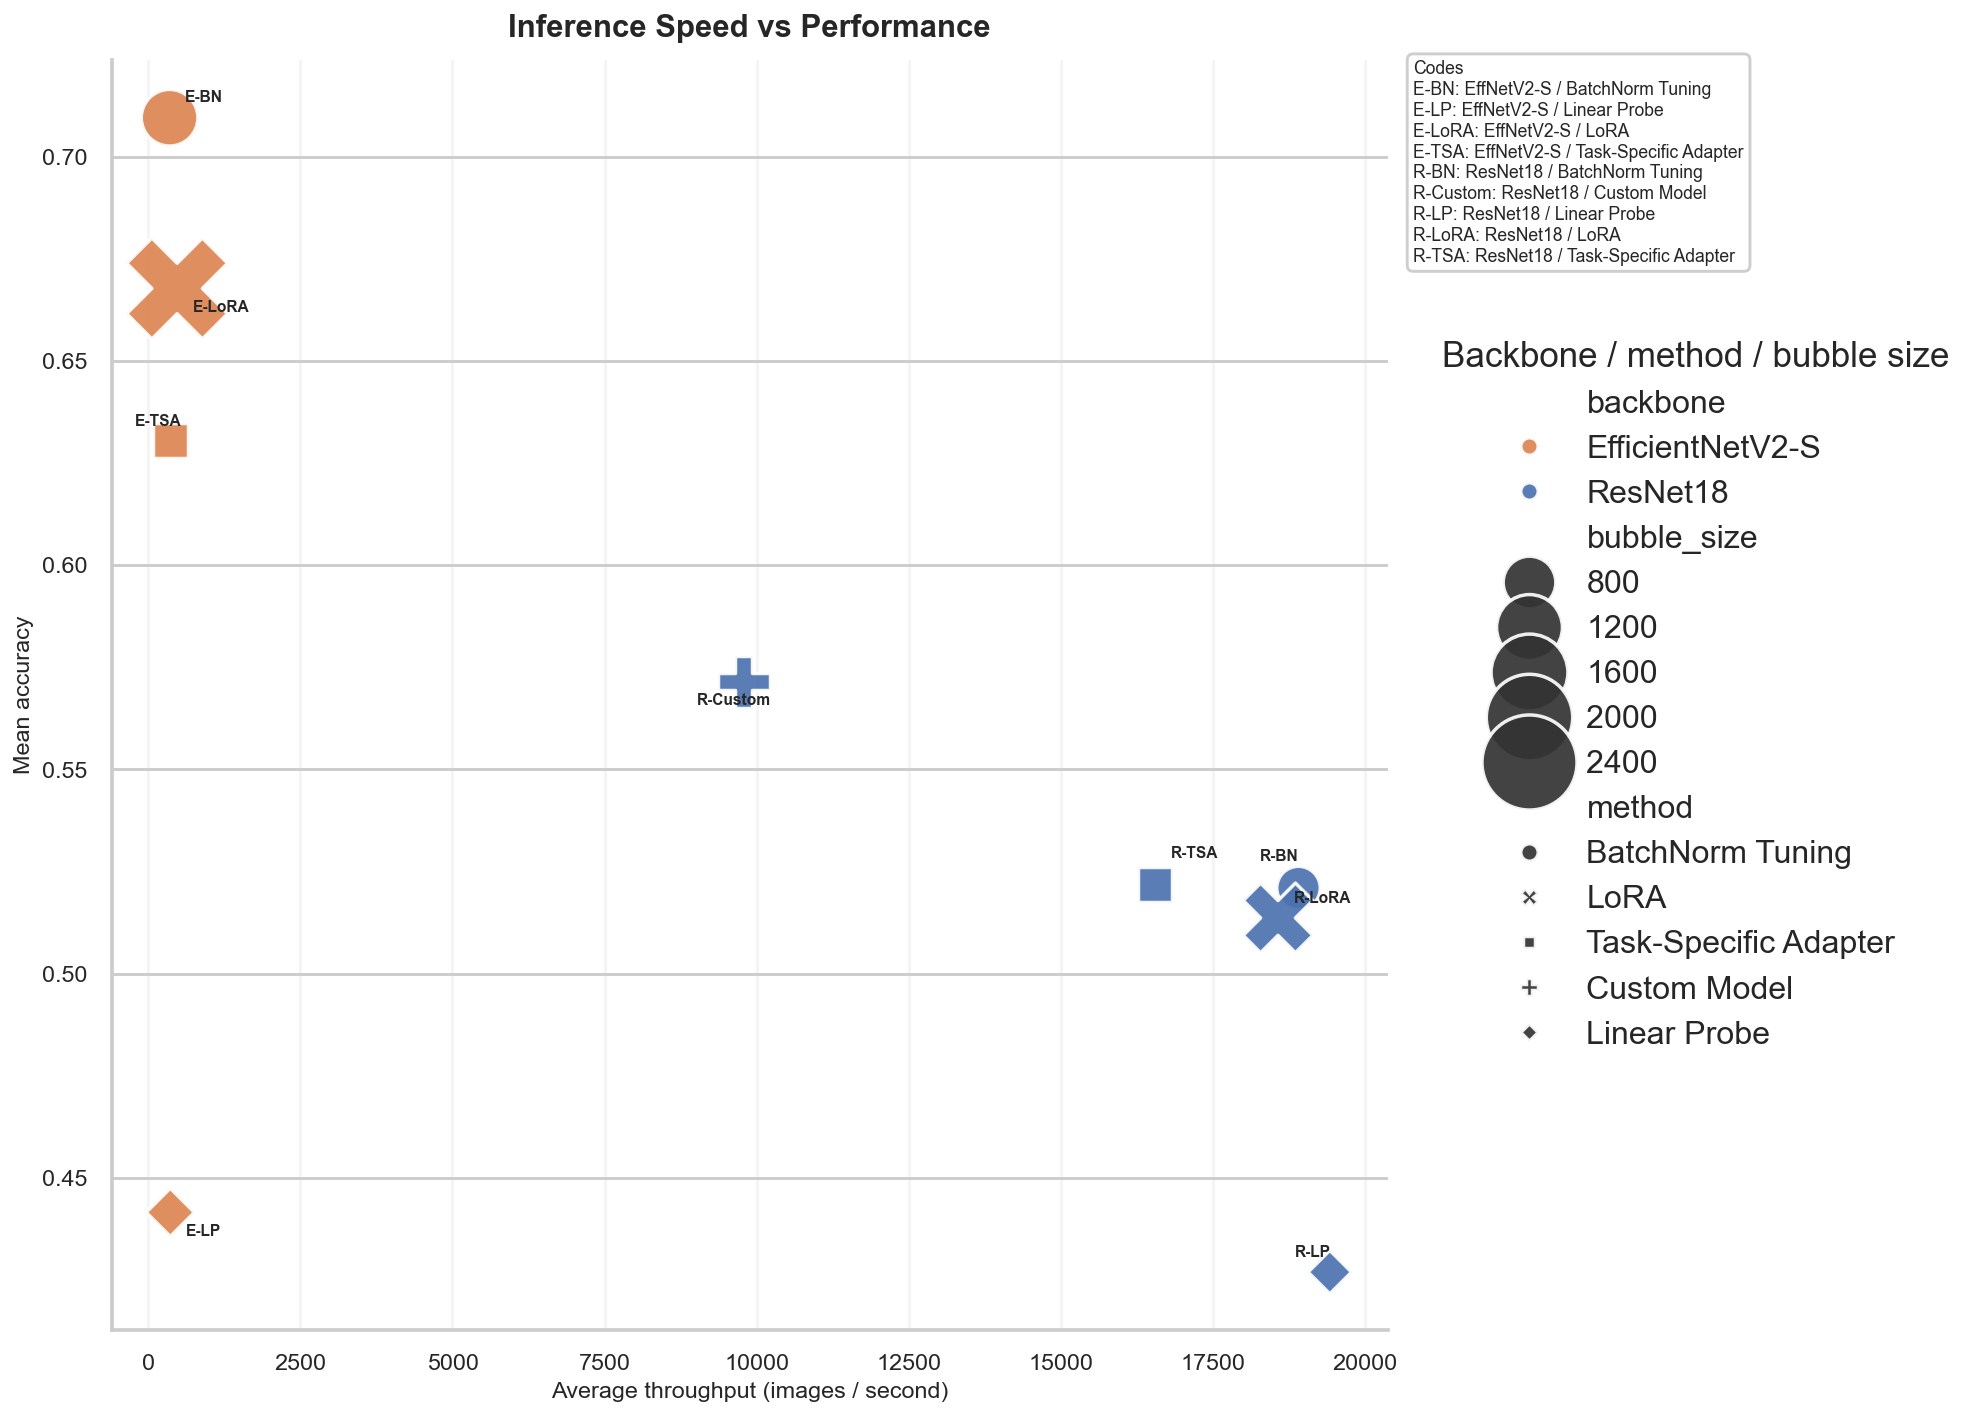

In [16]:
fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
sns.scatterplot(
    data=plot_df,
    x="avg_throughput",
    y="mean_accuracy",
    size="bubble_size",
    hue="backbone",
    style="method",
    palette=palette,
    sizes=(500, 2700),
    alpha=0.92,
    ax=ax,
)
annotate_codes(ax, plot_df, "avg_throughput", "mean_accuracy", dx=8, dy=8)
style_axis(ax, xlabel="Average throughput (images / second)", ylabel="Mean accuracy", title="Inference Speed vs Performance")
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="Backbone / method / bubble size", frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")
add_code_key(ax, plot_df, loc=(1.02, 1.0))
plt.show()


### Inference speed vs performance
The throughput-based plot leads to the same conclusion as the time-per-image analysis. ResNet18 provides strong speed, while EfficientNetV2-S provides stronger performance. The preferred model therefore depends on whether the application prioritizes accuracy or inference efficiency.


## Large baseline and inference comparison plots
This cell shows the two plots separately, one after the other, so each figure is larger and easier to explain.


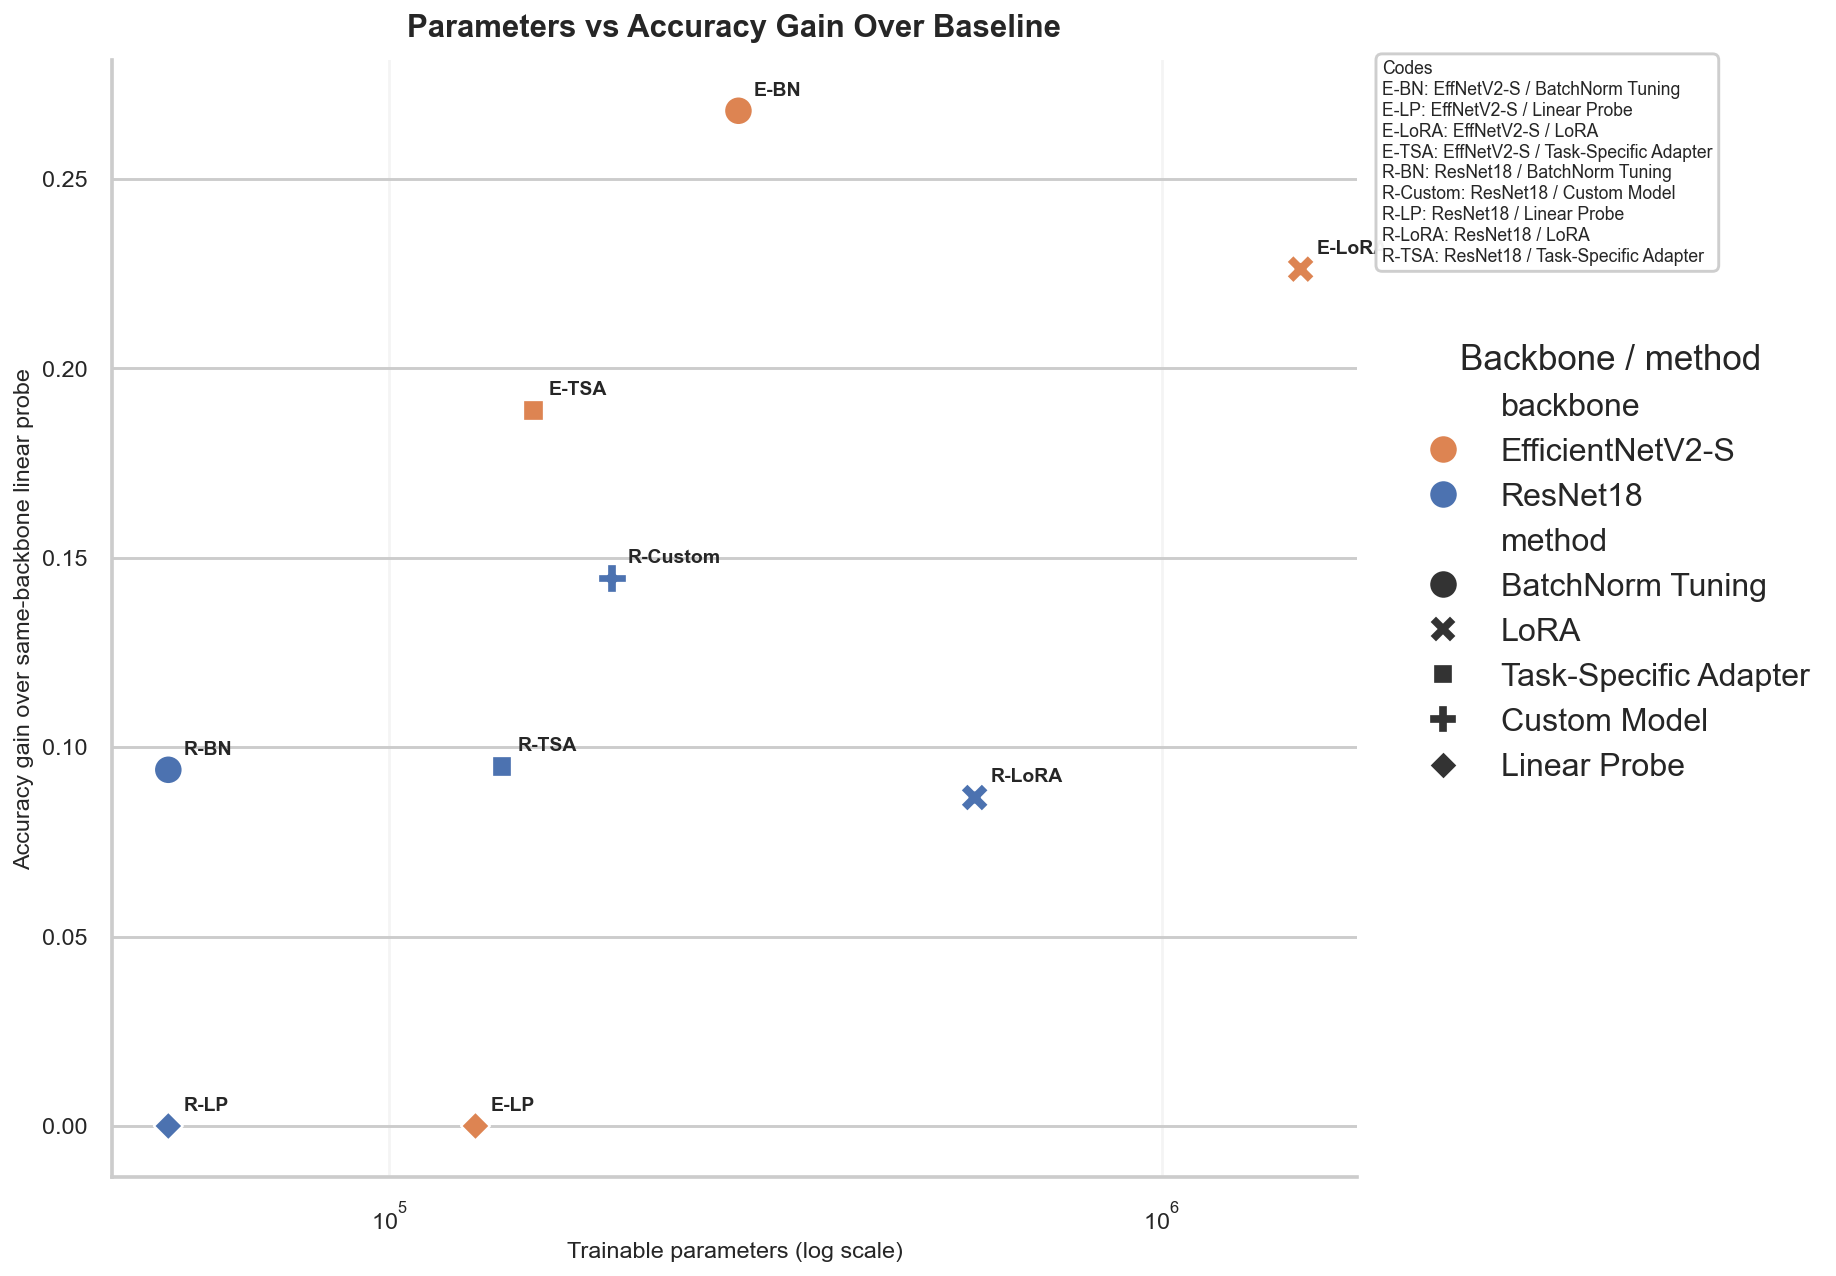

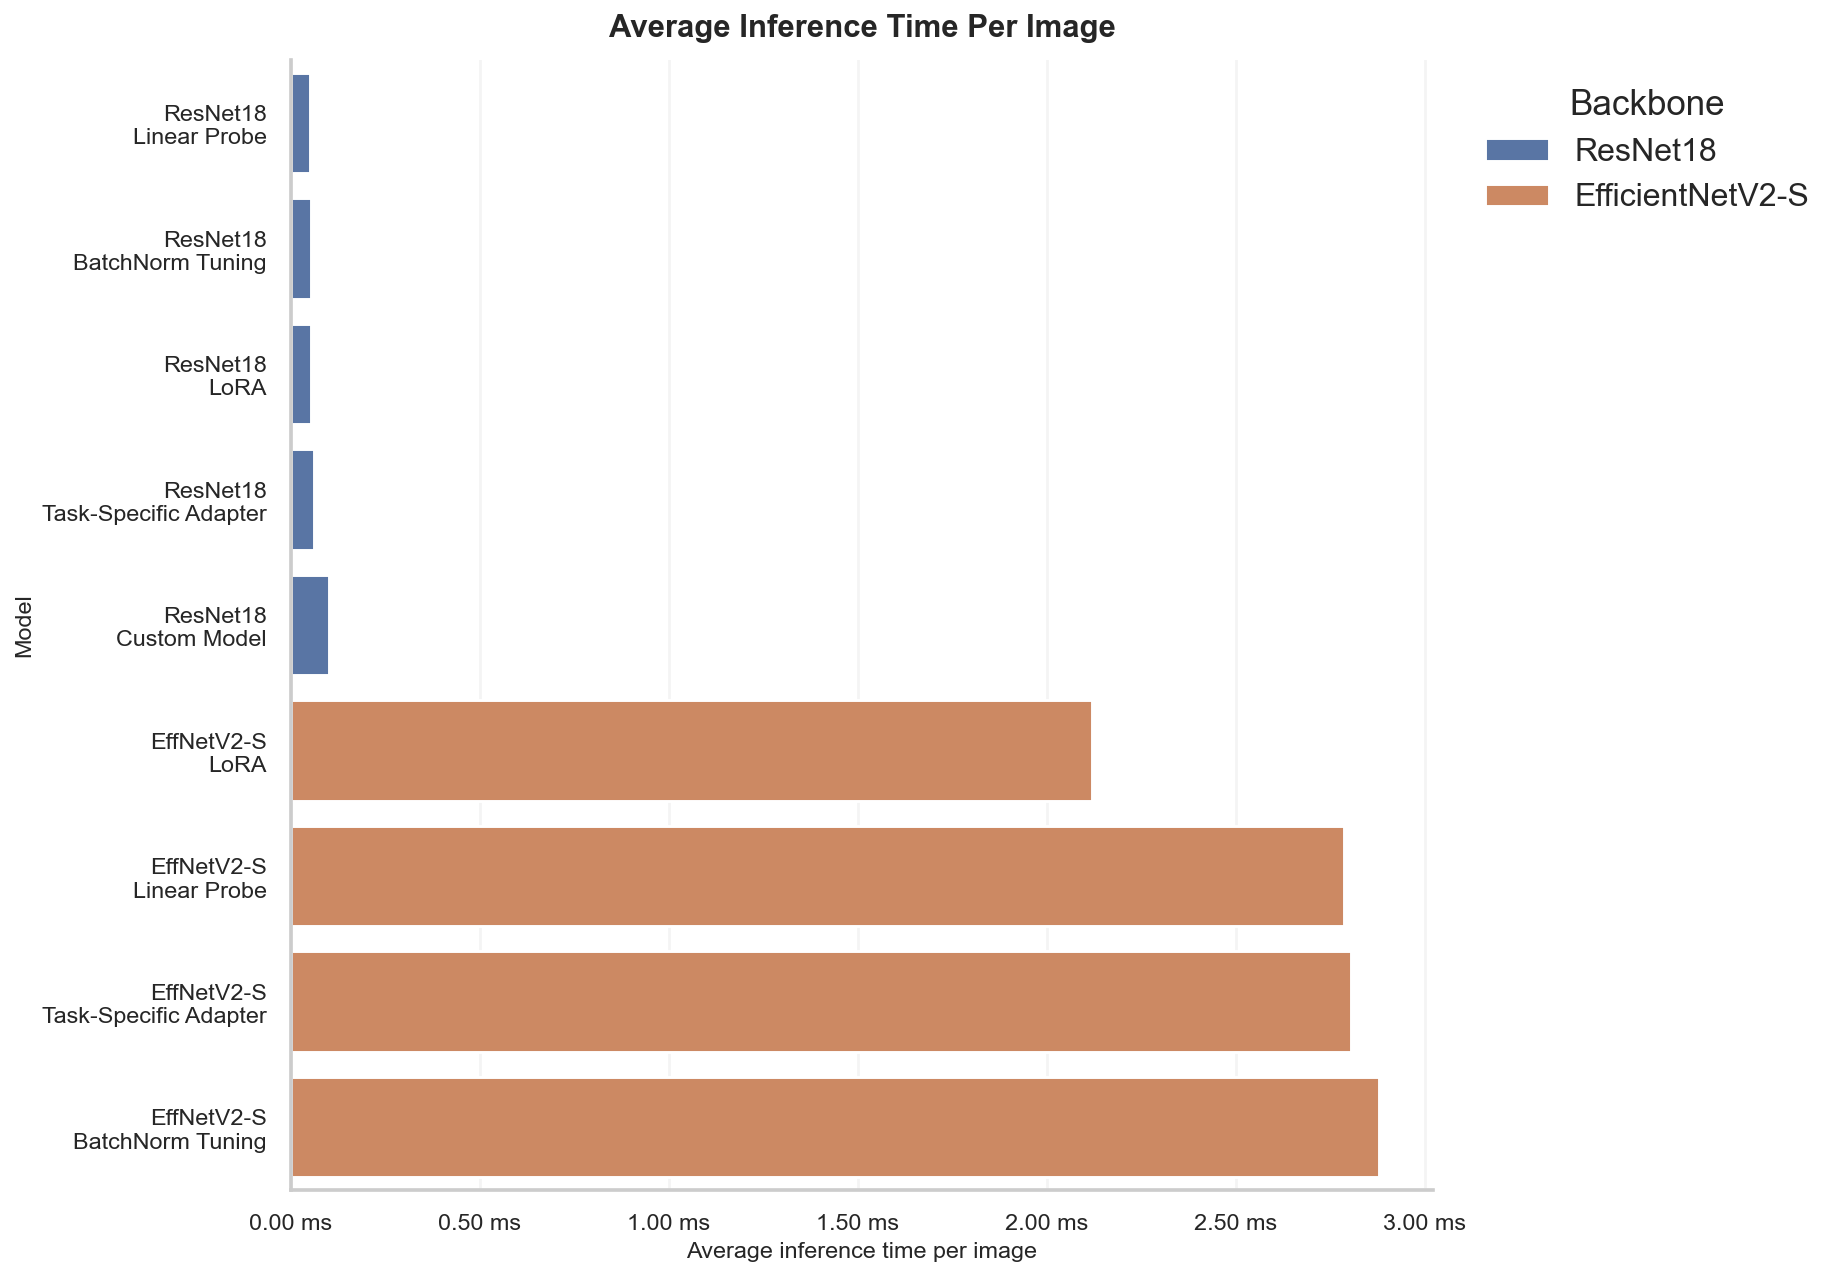

In [21]:
simple_plot_df = plot_df.copy()
simple_plot_df["short_backbone"] = simple_plot_df["backbone"].replace({"EfficientNetV2-S": "EffNetV2-S", "ResNet18": "ResNet18"})
simple_plot_df["simple_label"] = simple_plot_df["short_backbone"] + "\n" + simple_plot_df["method"]

fig, ax = plt.subplots(figsize=(13, 9), constrained_layout=True)
sns.scatterplot(
    data=simple_plot_df,
    x="trainable_parameters",
    y="accuracy_over_baseline",
    hue="backbone",
    style="method",
    palette=palette,
    s=220,
    ax=ax,
)
for row in simple_plot_df.itertuples():
    ax.annotate(row.short_model_name, (row.trainable_parameters, row.accuracy_over_baseline), textcoords="offset points", xytext=(8, 8), fontsize=10, weight="bold")
ax.set_xscale("log")
style_axis(ax, xlabel="Trainable parameters (log scale)", ylabel="Accuracy gain over same-backbone linear probe", title="Parameters vs Accuracy Gain Over Baseline")
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="Backbone / method", frameon=False, bbox_to_anchor=(1.02, 0.55), loc="center left")
add_code_key(ax, simple_plot_df, loc=(1.02, 1.0))
plt.show()

time_rank = simple_plot_df.sort_values("avg_time_per_image", ascending=True)
fig, ax = plt.subplots(figsize=(13, 9), constrained_layout=True)
sns.barplot(
    data=time_rank,
    x="avg_time_per_image",
    y="simple_label",
    hue="backbone",
    palette=palette,
    dodge=False,
    ax=ax,
)
style_axis(ax, xlabel="Average inference time per image", ylabel="Model", title="Average Inference Time Per Image")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x * 1000:.2f} ms"))
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="Backbone", frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.show()


### Parameters vs accuracy gain over baseline
Increasing trainable parameters does not always produce a proportional accuracy improvement. Some lightweight tuning strategies, such as BatchNorm tuning or task-specific adapters, achieve strong gains over linear probing with far fewer trainable parameters than LoRA. This shows that parameter efficiency is an important part of model comparison.

### Inference time per image
ResNet18 variants are much faster than EfficientNetV2-S variants in inference time per image. The gap is large enough that ResNet may be preferable in real-time or resource-constrained settings, even though its accuracy is lower. This highlights the practical trade-off between predictive quality and deployment cost.

### Conclusion
Overall, EfficientNetV2-S provides the best classification accuracy and robustness across clean and corrupted test sets, while ResNet18 provides much better inference efficiency. Parameter-efficient tuning methods improve substantially over linear probing, but their cost-effectiveness differs. BatchNorm tuning appears especially strong because it gives large accuracy gains without requiring as many trainable parameters as LoRA.
